In [5]:
#Baseline Algorithms, Function Implementations
from Single_ag_Environment import SingleSatelliteEnv
from gymnasium.utils.env_checker import check_env
import traceback
import numpy as np
print(type(SingleSatelliteEnv))
# This will catch many common issues
env = SingleSatelliteEnv()
try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print("Environment has issues:")
    traceback.print_exc()

<class 'type'>
Environment passes all checks!


In [34]:
#Here we implement Baseline CGR as a function that can be called 
def BaselineCGR(env,seed):
    
    init_observation,init_info=env.reset(seed)
    #print(init_observation)
    delivery_ratio_metric=None
    contact_energy_efficiency=None
    total_reward=0
    done=False
    while not done:
        action = 1
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
    #Next we need to extract final info from the episode
    initial_data_volume=info["Initial Data"]
    delivered_packets=info["Delivered Data"]
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    return total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    env.close()

    

In [50]:

def AdaptiveSorting(env,seed):
    initial_observation,initial_information=env.reset(seed)
    initial_data_volume=initial_observation["Remaining data"]*100
    contacts_available=initial_observation["contact plan"]
    sorted_matrix=np.zeros([10,2])
    current_contact_iterator=0
    #Next we must calculate the initial allocation of contacts
    j=0
    for i in contacts_available:
        sorted_matrix[j,0]=i
        sorted_matrix[j,1]=j
        j=j+1
    sorted_matrix=sorted_matrix[sorted_matrix[:, 0].argsort()]
    remaining_data=initial_data_volume
    decision_matrix=np.zeros([10,2])
    
    j=0
    for i in range(0,len(decision_matrix)-1):
        if (remaining_data>0):
            if sorted_matrix[j,0]<1:
                remaining_data=remaining_data-sorted_matrix[j,0]*10
                decision_matrix[i,0]=1
                decision_matrix[i,1]=sorted_matrix[j,1]
        j=j+1
    i=0
    #Next we must reorder the decision matrix
    
    done=False
    print(decision_matrix)
    sorted_decisions=decision_matrix[decision_matrix[:,1].argsort()]
    print(sorted_decisions)
    action_decision_matrix=np.zeros(10)
    for i in range(0,len(sorted_decisions)-1):
        action_decision_matrix[i]=sorted_decisions[i,0]
    obs=initial_observation
    i=0
    while not done:
        #print(i)
        print("Next Decision")
        print(decision_matrix[i])
        if action_decision_matrix[i]==0:
            #We don't use this contact
            action=0
            next_obs, reward, terminated, truncated, info = env.step(action)
        else:
            #We use the contact
            
            action=1
            next_obs, reward, terminated, truncated, info = env.step(action)
            #Next we need to determine if we successfully delivered any packets
            current_delivered=next_obs["Remaining data"]
            previous_delivered=obs["Remaining data"]
            if (current_delivered>previous_delivered):
                #We need to recalculate the decision matrix
                remaining_data=current_delivered*100
                aux_sorting_matrix=np.zeros([10,2])
                for j in range(0,9):
                    aux_sorting_matrix[j,0]=contacts_available[j]
                    aux_sorting_matrix[j,1]=j
                for j in range(0,i):
                    aux_sorting_matrix[j,0]=1
                    
                aux_sorting_matrix=aux_sorted_matrix[aux_sorted_matrix[:, 0].argsort()]
                decision_matrix=np.zeros([10,2])
                k=0
                for j in range(0,len(decision_matrix)-1):
                    if remaining_data>0:
                        if aux_sorted_matrix[k,0]<1:
                            remaining_data=remaining_data-aux_sorted_matrix[k,0]*10
                            decision_matrix[j,0]=1
                            decision_matrix[j,1]=aux_sorted_matrix[k,1]
                    k=k+1
                aux_sorted_decisions=decision_matrix[decision_matrix[:,1].argsort()]
                action_decision_matrix=np.zeros(10)
                for k in range(0,len(sorted_decisions)-1):
                    action_decision_matrix[k]=aux_sorted_decisions[k,0]
        obs=next_obs
        i=i+1
        if terminated==False and truncated==False:
            done=False
        else:
            done=True
    #Next we need to graph and log the results of the heuristic algorithm
    initial_data_volume=info["Initial Data"]
    delivered_packets=info["Delivered Data"]
    number_of_contacts=info["Number of Contacts"]
    excess_energy_expended=info["Energy Expended"]
    print("Delivered Packets")
    print(delivered_packets)
    print("Number of Contacts")
    print(number_of_contacts)
    return total_reward,intial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended
    env.close()


In [ ]:
#Basic debugging tests for sorting algorithm




/tmp/ipykernel_3439429/3589221399.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  CGR_delivery_ratio_vector[vector_index]=delivered_packets/initial_data_volume
/tmp/ipykernel_3439429/3589221399.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Sorting_delivery_ratio_vector[vector_index]=delivered_packets/initial_data_volume


[[1. 6.]
 [1. 4.]
 [1. 9.]
 [1. 8.]
 [1. 2.]
 [1. 5.]
 [1. 7.]
 [1. 0.]
 [1. 1.]
 [0. 0.]]
[[1. 0.]
 [0. 0.]
 [1. 1.]
 [1. 2.]
 [1. 4.]
 [1. 5.]
 [1. 6.]
 [1. 7.]
 [1. 8.]
 [1. 9.]]
Next Decision
[1. 6.]
Next Decision
[1. 4.]
Next Decision
[1. 9.]
Next Decision
[1. 8.]
Next Decision
[1. 2.]
Next Decision
[1. 5.]
Next Decision
[1. 7.]
Next Decision
[1. 0.]
Next Decision
[1. 1.]
Next Decision
[0. 0.]
Delivered Packets
31
Number of Contacts
8
Delivered Packets
31
Number of Contacts
8
[[1. 3.]
 [1. 5.]
 [1. 2.]
 [1. 1.]
 [1. 8.]
 [1. 9.]
 [1. 7.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
[[0. 0.]
 [0. 0.]
 [0. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 5.]
 [1. 7.]
 [1. 8.]
 [1. 9.]]
Next Decision
[1. 3.]
Next Decision
[1. 5.]
Next Decision
[1. 2.]
Next Decision
[1. 1.]
Next Decision
[1. 8.]
Next Decision
[1. 9.]
Next Decision
[1. 7.]
Next Decision
[0. 0.]
Next Decision
[0. 0.]
Delivered Packets
24
Number of Contacts
6
Delivered Packets
24
Number of Contacts
6
[[1. 3.]
 [1. 7.]
 [1. 8.]
 [1. 6.]
 [1. 2.]
 [1. 

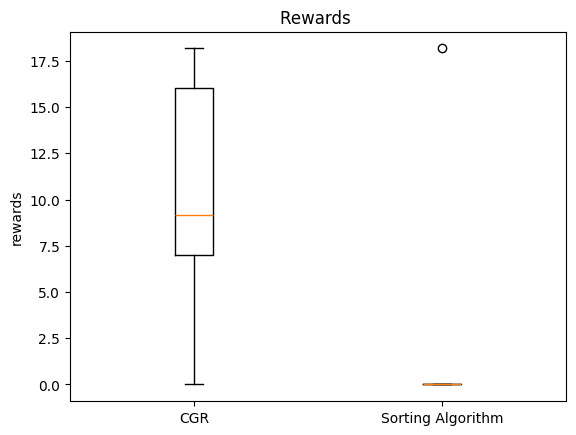

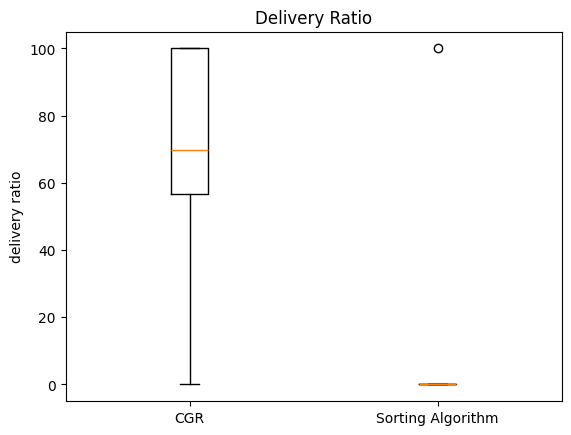

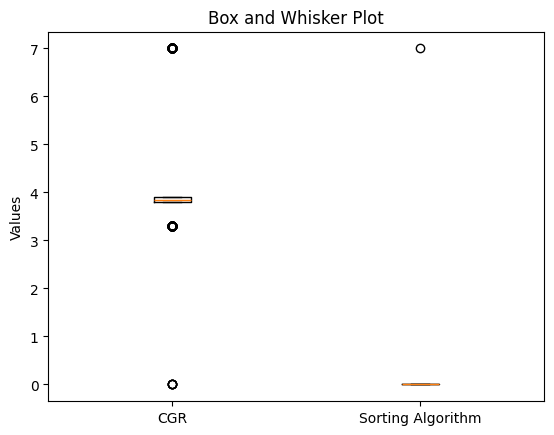

In [ ]:
#Next we need to test these baseline algorithms and produce delivery, reward and contact energy efficiency
#graphs
Number_of_Episodes=100
seeds=[50,51,52,53,54]
CGR_reward_vector=np.zeros(len(seeds)*Number_of_Episodes)
CGR_delivery_ratio_vector=np.zeros(len(seeds)*Number_of_Episodes)
CGR_mean_contact_energy_efficiency_vector=np.zeros(len(seeds)*Number_of_Episodes)
vector_index=0
for h in range(1,Number_of_Episodes):
        for b in seeds:
            total_reward,initial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=BaselineCGR(env,b)
            vector_index+=1
            CGR_reward_vector[vector_index]=total_reward
            CGR_delivery_ratio_vector[vector_index]=delivered_packets/initial_data_volume
            CGR_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/number_of_contacts

#Next we must make box plots these results



#Adaptive sorting Algorithm

Sorting_reward_vector=np.zeros(len(seeds)*Number_of_Episodes)
Sorting_delivery_ratio_vector=np.zeros(len(seeds)*Number_of_Episodes)
Sorting_mean_contact_energy_efficiency_vector=np.zeros(len(seeds)*Number_of_Episodes)
vector_index=0
for h in range(1,Number_of_Episodes):
        for b in seeds:
            total_reward,intial_data_volume,delivered_packets,number_of_contacts,excess_energy_expended=AdaptiveSorting(env,b)
            Sorting_reward_vector[vector_index]=total_reward
            Sorting_delivery_ratio_vector[vector_index]=delivered_packets/initial_data_volume
            print("Delivered Packets")
            print(delivered_packets)
            print("Number of Contacts")
            print(number_of_contacts)
            Sorting_mean_contact_energy_efficiency_vector[vector_index]=delivered_packets/number_of_contacts

import matplotlib.pyplot as plt
#Reward Plot
print(np.mean(Sorting_reward_vector))
plt.boxplot([CGR_reward_vector, Sorting_reward_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Rewards ")
plt.ylabel("rewards")
plt.show()

#Delivery Ratio Plot
plt.boxplot([CGR_delivery_ratio_vector, Sorting_delivery_ratio_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Delivery Ratio")
plt.ylabel("delivery ratio")
plt.show()
#Contact Energy Efficiency Plot
plt.boxplot([CGR_mean_contact_energy_efficiency_vector, Sorting_mean_contact_energy_efficiency_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Box and Whisker Plot")
plt.ylabel("Values")
plt.show()